### 빈 데이터 처리하기

In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic, Linux: NanumGothic)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("../data/netflix_titles.csv")

df['country'] = df['country'].fillna('No Data')
df['director'] = df['director'].replace(np.nan, 'No Data')
df['cast'] = df['cast'].replace(np.nan, 'No Data')
df.dropna(axis=0, inplace=True)
df.isna().sum() #Hurray  No null Values 

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

### 별도 column 생성(map 이용)

In [3]:
df['age_group'] = df['rating']
age_group_dic = {
    'G': 'All',
    'TV-G': 'All',
    'TV-Y': 'All',
    'PG': 'Older Kids',
    'TV-Y7': 'Older Kids',
    'TV-Y7-FV': 'Older Kids',
    'TV-PG': 'Older Kids',
    'PG-13': 'Teens',
    'TV-14': 'Young Adults',
    'NC-17': 'Adults',
    'NR': 'Adults',
    'UR': 'Adults',
    'R': 'Adults',
    'TV-MA': 'Adults'
}
df['age_group'] = df['age_group'].map(age_group_dic)
df.to_csv('../data/netflix_processed.csv', index=False)
nf = pd.read_csv('../data/netflix_processed.csv')
nf.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,age_group
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No Data,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Teens
1,s2,TV Show,Blood & Water,No Data,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Adults
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",No Data,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Adults


### apply(lambda), string을 datetime으로, 검색, 색상표

In [4]:
nf['title_length'] = nf['title'].apply(lambda x: len(x))
nf['release_year'] = pd.to_datetime(nf['release_year']).dt.year
nf['is_movie'] = nf['type'].apply(lambda x: 1 if x == 'Movie' else 0)
nf.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,age_group,title_length,is_movie
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No Data,United States,"September 25, 2021",1970,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Teens,20,1
1,s2,TV Show,Blood & Water,No Data,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",1970,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Adults,13,0


In [ ]:
sns.palplot(['#221f1f', '#b20710', '#e50914', '#f5f5f1'])
plt.title('넷플 색상표', loc='left', fontsize=16, y=1.2)
plt.show()

In [5]:
nf[nf['title'].str.contains('squid game', na=False, case=False)]
nf1 = nf[nf['director']=='Raúl Campos, Jan Suter']
nf1.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,age_group,title_length,is_movie
4749,s4750,Movie,Coco y Raulito: Carrusel de ternura,"Raúl Campos, Jan Suter","Coco Celis, Raúl Meneses",Mexico,"July 27, 2018",1970,TV-MA,57 min,Stand-Up Comedy,"A study in contrasts, comedy partners and good...",Adults,35,1


### value_counts(), str.split(', ') => to_list

<Axes: title={'center': 'RELEASE RATEs'}, xlabel='release_year'>

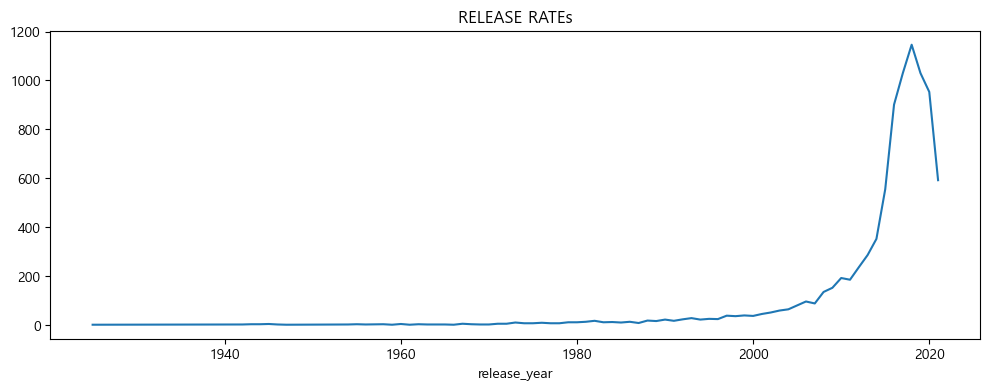

In [7]:
plt.figure(figsize = (12,4))
rate_count = df['release_year'].value_counts()
plt.title("RELEASE RATEs")
sns.lineplot(x =rate_count.index , y= rate_count.values)

In [ ]:
nf.type.value_counts()
type_count = nf['type'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(type_count, labels=type_count.index, autopct='%0.f%%',  explode=[0.05, 0.05], shadow=True, colors=['#b20710', '#221f1f'], startangle=90)
plt.suptitle('Movie & TV Show distribution', fontsize=15, fontweight='bold')
plt.title('We see more movies than TV shows on Netflix', fontfamily='serif',fontsize=12)
plt.show()

In [ ]:
# expand=True는 분할된 결과를 확장하여 여러 열로 변환
# stack( ) 함수로 각 영화의 장르를 개별적인 행으로 정리
# value_counts( )를 붙여 장르의 등장 횟수를 계산

genres = nf['listed_in'].str.split(', ', expand=True).stack().value_counts().head(25)
plt.figure(figsize=(12,6))
ax = sns.barplot(x=genres.values, y=genres.index, hue=genres.index, palette='RdGy',estimator=sum )
for i in range(len(genres)):
    ax.bar_label(ax.containers[i], fontsize=14) # pyright: ignore[reportArgumentType]
plt.xlabel('Count', fontsize=15)
plt.ylabel('Genre', fontsize=20)
plt.grid(axis='x')
plt.show()

In [14]:
# pd.set_option('display.max_rows', None) # 전체 row를 출력
nf['country_list'] = nf['country'].str.split(', ')
nf['country_list']
# 파이썬 리스트로 바꾼 country 열의 값에 explode( ) 함수를 적용하여 개별 행으로 분리
# explode( ) 함수는 country 열에 있는 파이썬 리스트의 원소를 분리하여 개별 행으로 만듧
nf_age_country = nf.explode('country_list')

nf_age_country[['country_list', 'country', 'title']].head(11)
nf_age_country[nf_age_country['title'].str.contains('sankofa', na=False, case=False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,age_group,title_length,is_movie,country_list
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1970,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",Adults,7,1,United States
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1970,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",Adults,7,1,Ghana
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1970,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",Adults,7,1,Burkina Faso
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1970,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",Adults,7,1,United Kingdom
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1970,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",Adults,7,1,Germany
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1970,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",Adults,7,1,Ethiopia


In [22]:
nf6 = nf[nf['duration'].str.split(' ').str.get(1)=='min']

nf_age_country_unstack = nf_age_country.groupby('age_group')['country_list'].value_counts().unstack()
nf_age_country_unstack.head()


country_list,,Afghanistan,Albania,Algeria,Angola,Argentina,Armenia,Australia,Austria,Azerbaijan,...,United Kingdom,"United Kingdom,",United States,"United States,",Uruguay,Vatican City,Venezuela,Vietnam,West Germany,Zimbabwe
age_group,,,,,,,,,,,,,,,,,,,,,
Adults,1.0,1.0,1.0,2.0,1.0,71.0,1.0,68.0,7.0,NaN,...,408.0,2.0,1803.0,1.0,9.0,NaN,2.0,3.0,3.0,2.0
All,NaN,NaN,NaN,NaN,NaN,5.0,NaN,18.0,NaN,NaN,...,63.0,NaN,255.0,NaN,2.0,NaN,NaN,1.0,1.0,1.0
Older Kids,NaN,NaN,NaN,NaN,NaN,5.0,NaN,40.0,3.0,NaN,...,145.0,NaN,694.0,NaN,2.0,1.0,NaN,NaN,NaN,NaN
Teens,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,NaN,NaN,...,84.0,NaN,433.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Young Adults,1.0,NaN,NaN,1.0,NaN,10.0,NaN,21.0,2.0,1.0,...,103.0,NaN,495.0,NaN,1.0,NaN,2.0,3.0,1.0,NaN


### hitmap 그리기

In [10]:
nf[nf['title'].str.contains('sankofa', na=False, case=False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,age_group,title_length,is_movie,country_list
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1970,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",Adults,7,1,"[United States, Ghana, Burkina Faso, United Ki..."


### Rating

<Axes: xlabel='count', ylabel='rating'>

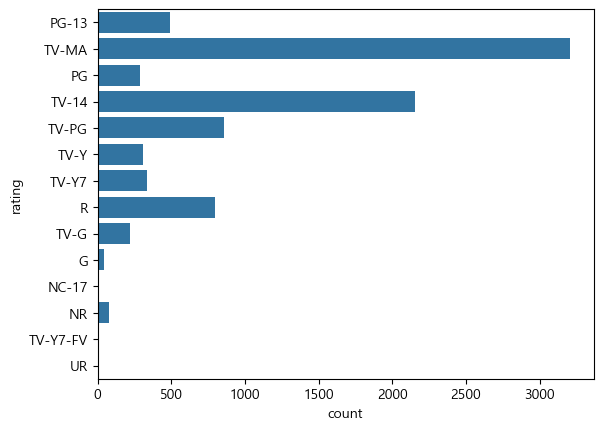

In [ ]:
sns.countplot(nf.rating)

In [ ]:
nf["rating"].unique()

In [ ]:
df7 = nf.duration.value_counts().sort_values(ascending=False).head(10)

In [ ]:
sns.barplot(x=df7.index, y=df7.to_list())

In [ ]:
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

text = " ".join(review for review in df.listed_in.astype(str))
print (f"There are {len(text)} words in the combination of all cells in column title.")

# Generate a word cloud image
wordcloud = WordCloud(background_color="black", width=800, height=400).generate(text)

# Display the generated image:
# the matplotlib way:

plt.axis("off")
plt.figure( figsize=(40,20))
plt.tight_layout(pad=0)
plt.imshow(wordcloud, interpolation='bilinear')
plt.show()